## Homework 7: Clustering & PCA with High-Dimensional Data
### Zachary Griffin; 4/29/26
Objective:
To determine if K-Means or DBSCAN can accurately breast cancer patients into meaningful clusters and to evaluate the impact of PCA on high-dimensional clustering.
### Part 1: Initial Clustering 
Load the dataset (from sklearn.datasets import load_breast_cancer

data = load_breast_cancer )

drop the "target" column (Diagnosis). You should only have the 30 numerical features.
Standardization: Apply StandardScaler. This is mandatory as features have vastly different scales. Then Cluster the data using k-means and DBSCAN algorithm.
 - K-Means: Use the Elbow Method to suggest an optimal K, But if not 2, use K=2
 - DBSCAN: Attempt to find an appropriate eps and min_samples.
 - Metrics: Calculate the Silhouette Score for both
 
### Part 2: Dimensionality Reduction (PCA)
    - Perform PCA: Run PCA on your scaled 30-feature data.
    - Variance Analysis: Plot the Cumulative Explained Variance ratio.
    - Identify the minimum number of Principal Components (PCs) needed to capture ~85% of the variance.
    - Interpretation: Plot the heatmap of loading. Also identify which 3 original features contribute the most to Principal Component 1?
    
### Part 3: Clustering Using Principal Components
    - Reduce your dataset to the number of PCs identified in Part 2.
    - Run K-Means (K=2) on the PCA-transformed data.
    - Run DBSCAN on the PCA-transformed data.
    - Metric Comparison: Compare the Silhouette Score of the PCA-based clusters against the 30-feature clusters from Part 1.
    
   
### Part 4: Visual Validation
    - Scatter Plot: Create a 2D plot using PC1 and PC2, Color the points using your K-Means labels (If your Kmeans .
    - Create a second version of the plot colored by the original labels (target).
    - How closely did the unsupervised K-Means clusters match the actual medical diagnosis? 

## Part 1 : Initial Clustering

In [64]:
#import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')



In [65]:
# Load dataset
cancer = load_breast_cancer() 
# since breast_cancer is a class, 'target' would have to be assigned to the df explicitly like was for the logistic regression activity
# can't I just *not* assign it, and thus not have to drop it?

X_cancer = StandardScaler().fit_transform(cancer.data)

print(X_cancer.shape) # if it has 30 columns that it doesn't include the 'target' columns



(569, 30)


### Kmeans: 
Use the Elbow Method to suggest an optimal K, But if not 2, use K=2 (Within-Cluster SUm of Squares)

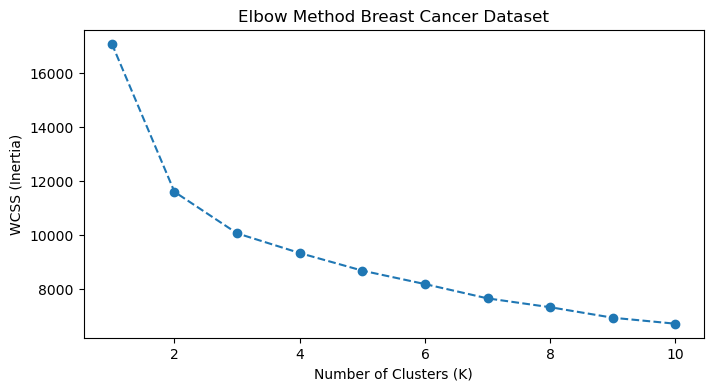

In [66]:
# find the optimal k that minimizes error
wcss = []
k_range = range(1,11)

for k in k_range:
    kmeans = KMeans(n_clusters = k, random_state = 23)
    kmeans.fit(X_cancer)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method Breast Cancer Dataset')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.show() 

Cluster CEnters: 
 [[-0.48299485 -0.23904142 -0.50041892 -0.47814154 -0.3110035  -0.52601873
  -0.57903569 -0.58717117 -0.30908386 -0.1491409  -0.42798514 -0.02110994
  -0.43097168 -0.40175149 -0.02383127 -0.37020054 -0.3345976  -0.39771232
  -0.07493017 -0.23682231 -0.51785387 -0.25147802 -0.53231144 -0.49935772
  -0.31607814 -0.49224121 -0.53684332 -0.58010099 -0.30335497 -0.33672889]
 [ 0.93362406  0.4620646   0.96730462  0.92424266  0.60116657  1.01678879
   1.11927003  1.13499581  0.59745592  0.28828783  0.82729086  0.0408053
   0.83306382  0.77658149  0.0460656   0.71559384  0.64677371  0.76877382
   0.14483925  0.45777508  1.00100618  0.48610441  1.02895252  0.96525332
   0.61097579  0.95149718  1.0377126   1.12132923  0.58638203  0.65089347]]


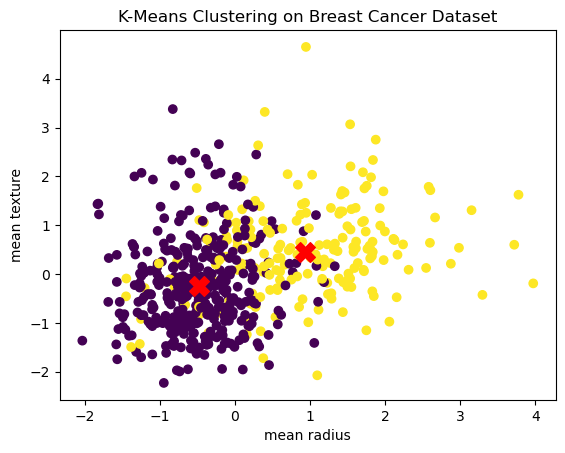

In [67]:
# for K = 2
kmeans = KMeans(n_clusters =2, random_state = 23)
kmeans.fit(X_cancer)

# Get Cluster labels and centroid locations
klabels = kmeans.labels_
kcentroids = kmeans.cluster_centers_

print("Cluster CEnters: \n", kcentroids)

#Plot! using two of the features 
plt.scatter(X_cancer[:, 0], X_cancer[:,1], c= klabels, cmap ='viridis')
plt.scatter(kcentroids[:,0], kcentroids[:,1], c = 'red', marker = 'X', s = 200)
plt.xlabel(cancer.feature_names[0])
plt.ylabel(cancer.feature_names[1])
plt.title("K-Means Clustering on Breast Cancer Dataset")
plt.show()

### DBSCAN

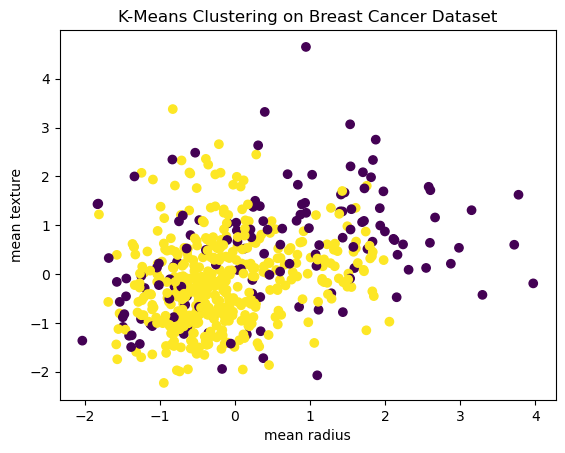

In [68]:
db_cancer = DBSCAN(eps = 3, min_samples = 10).fit(X_cancer) #where eps is epsilon, for radius within which needs minimum number of neighbors
# found it strange that with a epsilon of 1 or less I got a single cluster
# I'm really uncertain how i'm supposed to tell what's the best here

# get cluster labels 
db_labels = db_cancer.labels_

#Plot!
 # using two of the features 
plt.scatter(X_cancer[:, 0], X_cancer[:,1], c= db_labels, cmap = 'viridis')
plt.xlabel(cancer.feature_names[0])
plt.ylabel(cancer.feature_names[1])
plt.title("K-Means Clustering on Breast Cancer Dataset")
plt.show()

I looked up the Silhouette score,  got really confused, and did not have time to figure it out. 

## Part 2 Dimensionality Reduction (PCA)


In [70]:
# Perform PCA: Run PCA on your scaled 30-feature data.

# X_cancer is already the scaled from above

#I do want to know feature names thoug:
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

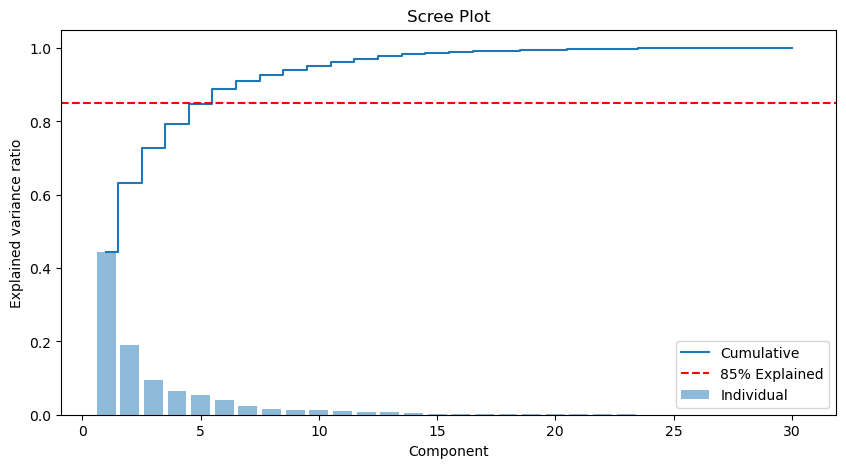

In [77]:
# PCA analysis

pca = PCA()
score = pca.fit_transform(X_cancer)


# Cumulative Explained Variance Ratio: want the PCAs to capture 85%
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.5, label='Individual')
plt.step(range(1, len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_), where='mid', label='Cumulative')
plt.axhline(y = .85, color = 'red', linestyle = 'dashed', linewidth = 1.5, label = '85% Explained')
plt.ylabel('Explained variance ratio'); plt.xlabel('Component'); plt.title('Scree Plot'); plt.legend(); plt.show()

Need five components to achieve 85% of variation explained

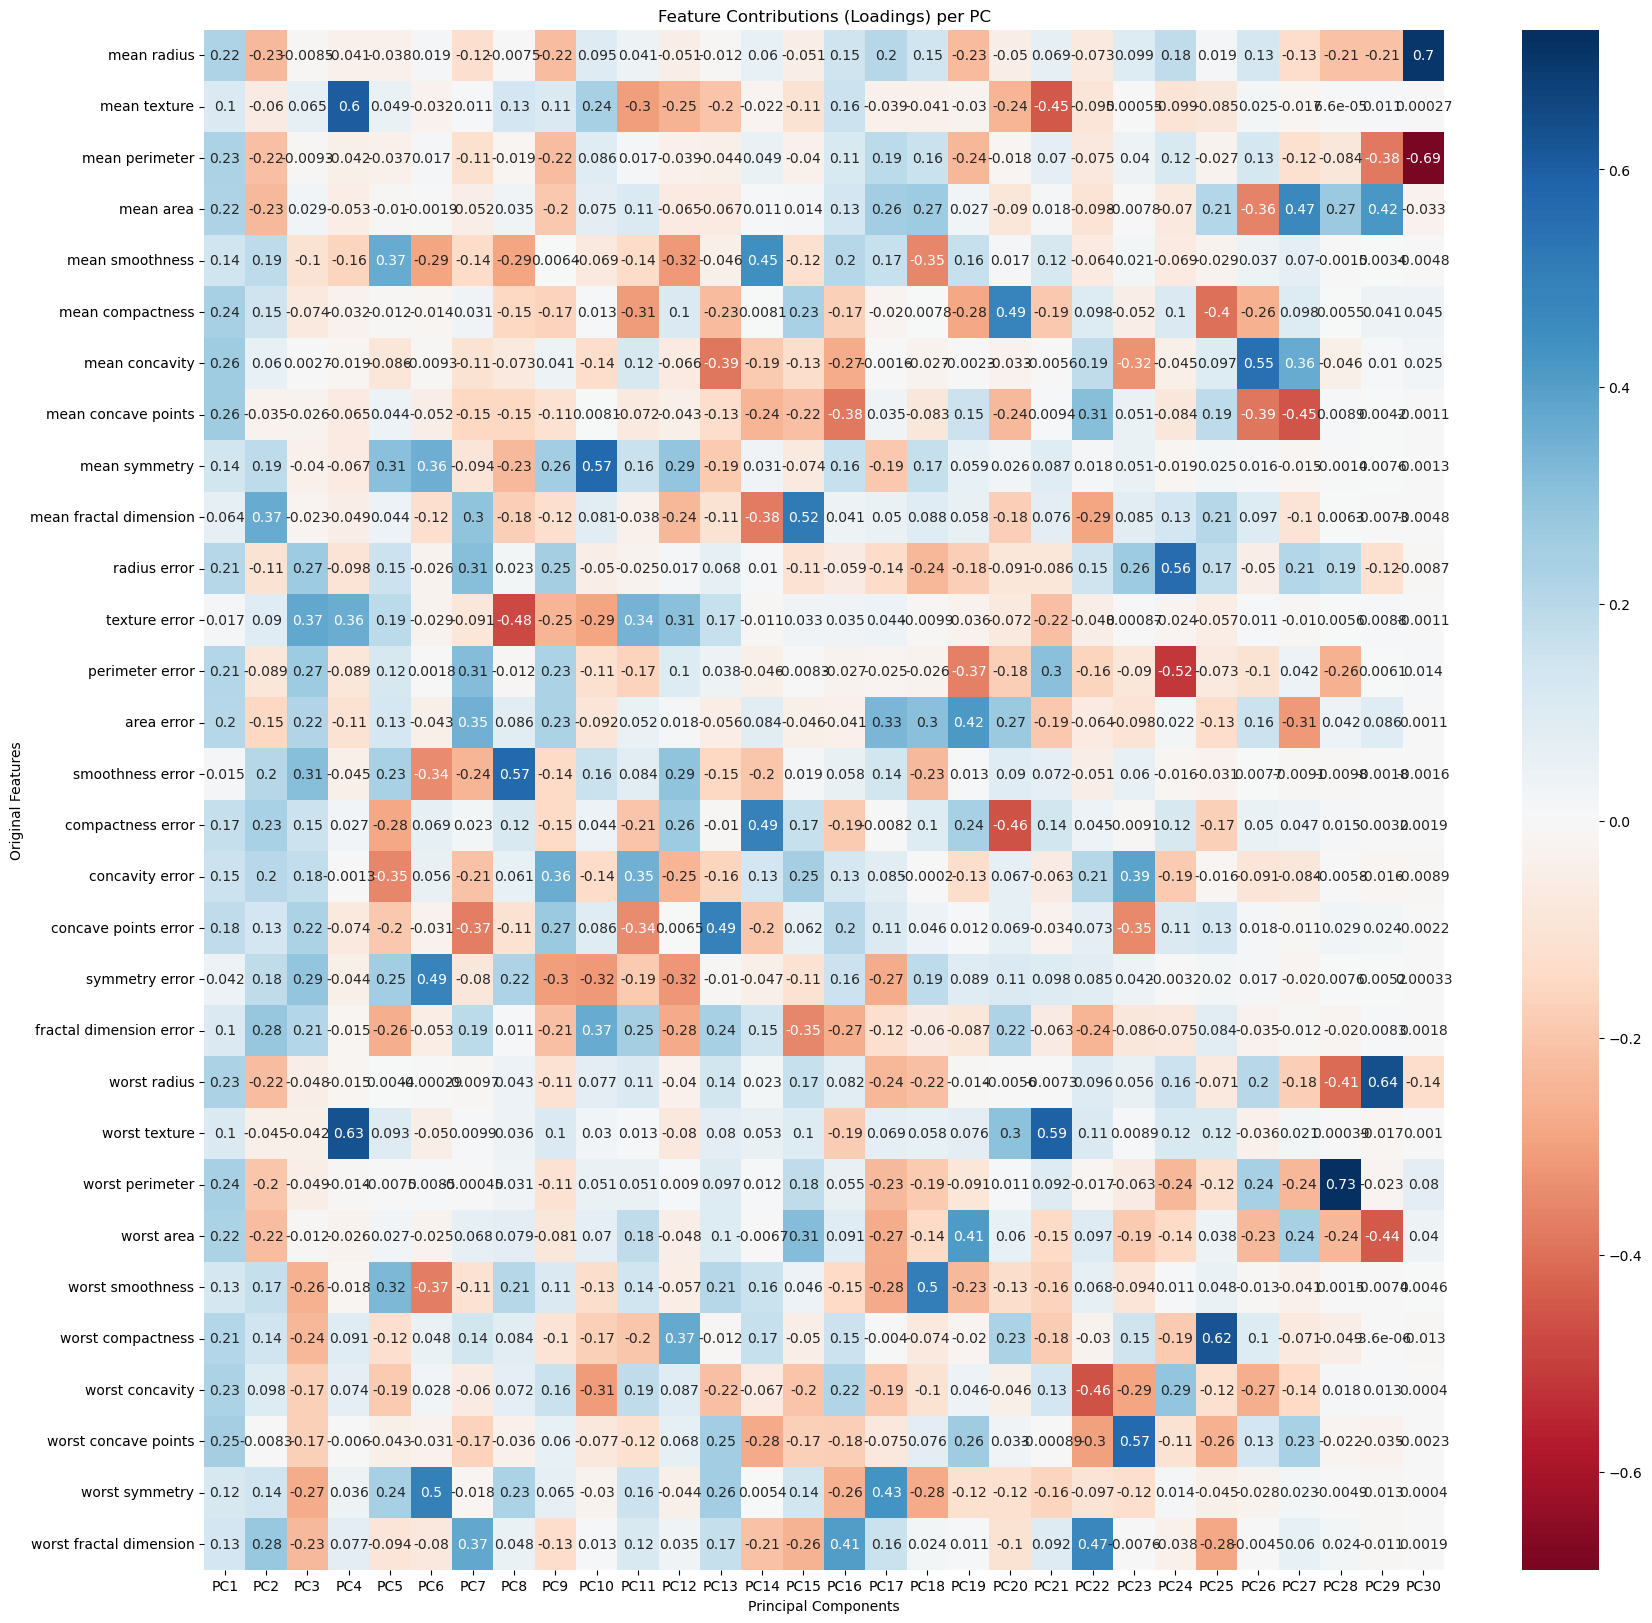

In [83]:
# Loadings Heatmap
loadings = pd.DataFrame(
    pca.components_.T,
    columns = [f'PC{i+1}' for i in range(pca.n_components_)],
    index = cancer.feature_names)

#HEATMAP!!!
plt.figure(figsize=(20, 20))
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0)
plt.title('Feature Contributions (Loadings) per PC')
plt.ylabel('Original Features')
plt.xlabel('Principal Components')
plt.show()

In [86]:
# Top contributors to PC! are mean concavity, mean concave points, and worst concave points (from looking at the plot)
# Identifying the same via code: 
top_pc1 = loadings['PC1'].sort_values(ascending = False)
top_pc1.head(3)

mean concave points     0.260854
mean concavity          0.258400
worst concave points    0.250886
Name: PC1, dtype: float64

## Part 3: Clustering Using Principal Components

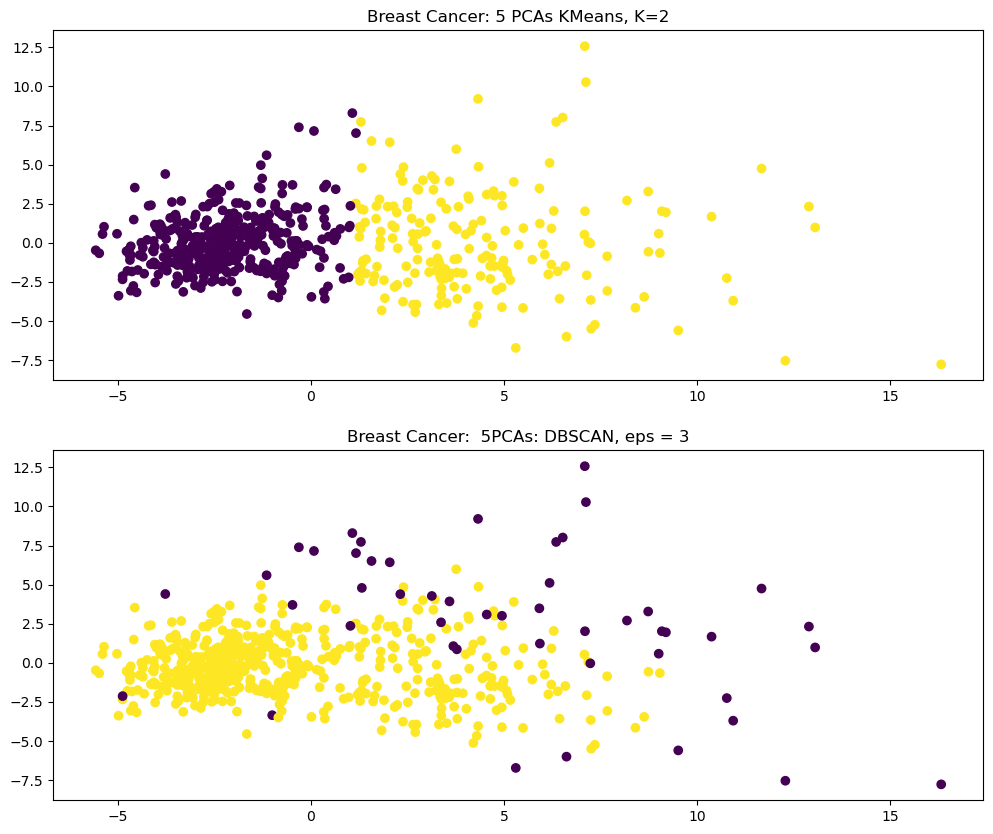

In [92]:
# Reducing to five components 
pca_df = pd.DataFrame(data=score[:,:5], columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5']) 

# the values were already scaled when the PCA was run, so I shouldn't need to scale them again?
X_pca = pca_df.values

#run k means and DBSCAN on the reduced PCAs
km_pca = KMeans(n_clusters = 2, random_state = 23).fit(X_pca)
db_pca = DBSCAN(eps = 3, min_samples = 10).fit(X_pca)

# plot!
fit, axes = plt.subplots(2,1, figsize =(12,10))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c= km_pca.labels_, cmap='viridis')
axes[0].set_title("Breast Cancer: 5 PCAs KMeans, K=2")

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c= db_pca.labels_, cmap='viridis')
axes[1].set_title("Breast Cancer:  5PCAs: DBSCAN, eps = 3")
plt.show()



## Part 4 Visual Validation 

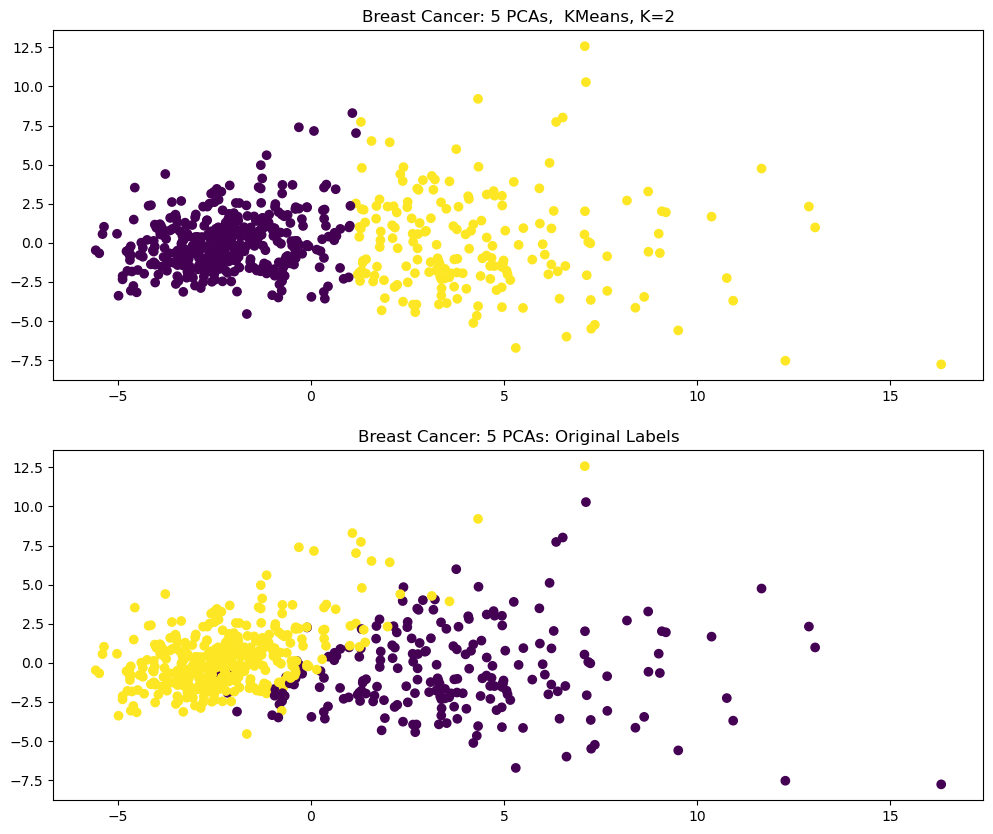

In [95]:
## scatter plot using only PC1 and PC2, colored using Kmeans labels ( the top plot above, repeated) and the PC! and PC2 colored by original labels

fit, axes = plt.subplots(2,1, figsize =(12,10))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c= km_pca.labels_, cmap='viridis')
axes[0].set_title("Breast Cancer: 5 PCAs,  KMeans, K=2")

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c= cancer.target, cmap='viridis')
axes[1].set_title("Breast Cancer: 5 PCAs: Original Labels")
plt.show()



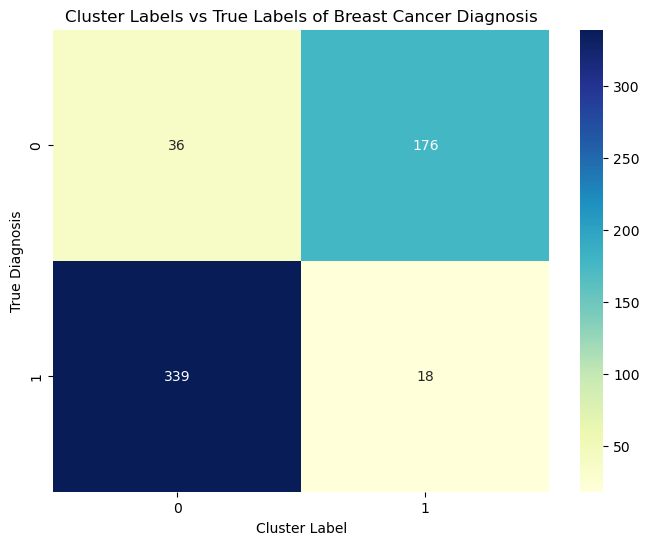

In [96]:
# They look like they match pretty well (the groups got flipped, obviously)

df_temp = pd.DataFrame({'True Diagnosis': cancer.target, 'Cluster': kmeans.labels_})
ct = pd.crosstab(df_temp['True Diagnosis'], df_temp['Cluster'])

# Plot as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(ct, annot=True, cmap="YlGnBu", fmt='d')
plt.title('Cluster Labels vs True Labels of Breast Cancer Diagnosis')
plt.xlabel('Cluster Label')
plt.ylabel('True Diagnosis')
plt.show()